## Setup

Run this notebook from a local clone of the [svm-gmu](https://github.com/SushrutGaikwad/svm-gmu) repository. From the repo root, install the project and launch Jupyter with [uv](https://docs.astral.sh/uv/):

```bash
uv sync
uv run jupyter lab
```

The next cell puts the repo's `src/` and `experiments/` folders on the import path, so `svm_gmu` and the shared `_common` helper import from your local clone. Figures are rendered with your local LaTeX (`pdflatex`) and saved into the report's `graphics/` directory.

In [1]:
import sys
from pathlib import Path


def _add_repo_to_path():
    """Put the repo's experiments/ and src/ folders on sys.path.

    Locates the svm-gmu repository by searching upward from the working
    directory, so the notebook runs from any local clone regardless of where
    Jupyter was started.
    """
    for base in (Path.cwd().resolve(), *Path.cwd().resolve().parents):
        if (base / "experiments" / "_common.py").exists():
            exp, src = base / "experiments", base / "src"
        elif (base / "_common.py").exists():
            exp, src = base, base.parent / "src"
        else:
            continue
        for path in (str(exp), str(src)):
            if path not in sys.path:
                sys.path.insert(0, path)
        return
    raise RuntimeError(
        "Could not find the svm-gmu repository. Run this notebook from a local "
        "clone (for example, `uv run jupyter lab` from the repo root)."
    )


_add_repo_to_path()

import numpy as np
import matplotlib.pyplot as plt

import _common as C

# Render figures with the report's LaTeX serif font (pdflatex + lmodern).
C.configure_pgf()
C.GRAPHICS_DIR.mkdir(parents=True, exist_ok=True)

# High-Dimensional Scaling of Sampling vs Closed-Form SVM-GMU

This experiment asks: as the feature dimension $d$ grows, how many Monte Carlo samples per training example does a standard SVM need to match the closed-form SVM-GMU boundary?

**Setup.** For each target dimension $d$ we build a *purpose-built, genuinely $d$-dimensional* dataset (see `C.make_highdim_gmm_dataset`): two close classes in $\mathbb{R}^d$, where each of the $n=10$ examples is a genuine 3-component isotropic Gaussian mixture, $f(x) = \sum_m \tfrac{1}{3}\,\mathcal{N}(x;\, c_i + s\,u_i^{(m)},\, \sigma^2 I_d)$, whose components fill all $d$ coordinates. Because every example is a real mixture ($M=3>1$), the closed-form reference is literally SVM-GMU. (This replaces an earlier construction that lifted the 2D `close_separable` data with nuisance-noise dimensions; that version kept the signal in a 2D subspace, so it was replaced by a genuinely high-dimensional one.)

**Headline question: $N^*(d)$.** For each $d$ we sweep a ladder of sample counts $N$ (samples per example), train a standard SVM on the resulting $10N$-point cloud, and record how close its boundary gets to the closed-form SVM-GMU boundary (angle in degrees). $N^*(d)$ is the smallest $N$ at which the angle falls below a threshold $\tau$. If sampling is harder in higher dimensions, $N^*(d)$ should grow with $d$.

**Secondary view: fixed-budget angle vs $d$.** For two fixed budgets $N \in \{1000, 10000\}$ we plot the median angle as a function of $d$. If higher dimensions demand more samples, the angle should increase with $d$ for any fixed $N$.

**Third view: fixed-budget decision-function RMS ($\Delta^{\mathrm{mc}}$) vs $d$.** For the same two budgets we plot the Monte Carlo decision-function RMS (the RMS difference between the two unit-normalized decision functions, evaluated over a fixed 20000-point cloud drawn from the mixtures). This is the dimension-agnostic replacement for Experiment 2's grid RMS, and like the angle it should grow with $d$ at any fixed budget.

**Fourth view: fixed-budget offset difference ($\Delta^{\mathrm{offset}}$) vs $d$.** The third boundary-disagreement metric, the difference of the signed origin-to-boundary distances. Unlike the angle and the RMS, the offset is a single scalar that finitely many samples pin down about equally well at any dimension, so it stays small and roughly flat across $d$ (shrinking with the budget). The dimensional difficulty of sampling shows up in the boundary's *orientation*, not its *position*.

This notebook runs the full 30-seed sweep ($d$ up to $50$, ladder to $3\times10^4$) and saves the report figures `high_dim_nstar.pgf`, `high_dim_fixed_budget.pgf`, `high_dim_rms.pgf`, and `high_dim_offset.pgf`. The first run is slow; results are cached to `experiments/.cache/` so re-runs are instant. Set `FORCE_RECOMPUTE = True` to recompute.

In [2]:
# Inlined high-dimensional sweep engine (the *_figs.py scripts are gone).
# Per-example d-dimensional GMM dataset parameters (see make_highdim_gmm_dataset).
D_VALUES_FULL = [2, 3, 5, 10, 20, 35, 50]
N_LADDER_FULL = [10, 30, 100, 300, 1000, 3000, 10000, 30000]
R_SEEDS_FULL = 30

N_PER_CLASS = 5      # examples per class -> n = 10
M_COMPONENTS = 3     # components per example (a genuine SVM-GMU mixture)
SEP = 2.0            # class-center separation along the first axis
JITTER = 0.5         # off-axis within-class jitter (boundary genuinely d-dim)
SPREAD = 0.9         # component-mean offset from the example center
SIGMA = 1.1          # per-component isotropic std

TAUS = [1.0, 2.0]            # degrees; primary curve uses tau = 2.0
FIXED_BUDGETS = [1000, 10000]
CACHE_DIR = Path(C.__file__).resolve().parent / ".cache"


def run_highdim_sweep(d_values, n_ladder, seeds):
    """Return dict with angle/offset/rms arrays of shape (len(d), len(seeds), len(ladder))."""
    nd, ns, nl = len(d_values), len(seeds), len(n_ladder)
    angle = np.full((nd, ns, nl), np.nan)
    offset = np.full((nd, ns, nl), np.nan)
    rms = np.full((nd, ns, nl), np.nan)
    for di, d in enumerate(d_values):
        for si, seed in enumerate(seeds):
            rng = np.random.default_rng(seed)
            X, y, su = C.make_highdim_gmm_dataset(
                d, rng, n_per_class=N_PER_CLASS, n_components=M_COMPONENTS,
                sep=SEP, jitter=JITTER, spread=SPREAD, sigma=SIGMA,
            )
            w_ref, b_ref = C.fit_gmu(X, y, su)
            eval_cloud = C.mc_eval_cloud(su, 2000, rng)
            for ni, n in enumerate(n_ladder):
                Xc, yc = C.build_sample_cloud(su, y, n, rng)
                w_n, b_n = C.fit_gmu(
                    Xc, yc, None, max_iter=C.svm_iter_for(len(Xc)),
                    seed=C.SVM_SEED, batch_size=256,
                )
                a, o, r = C.boundary_metrics(w_n, b_n, w_ref, b_ref, eval_cloud)
                angle[di, si, ni], offset[di, si, ni], rms[di, si, ni] = a, o, r
            print(f"d={d:>3d} seed={seed}: angle@maxN={angle[di, si, -1]:.3f}")
    return {
        "d_values": np.array(d_values), "n_ladder": np.array(n_ladder, dtype=float),
        "seeds": np.array(seeds),
        "angle": angle, "offset": offset, "rms": rms,
    }


def make_nstar_figure(res):
    d_values = res["d_values"]
    cap = res["n_ladder"][-1]
    fig, ax = plt.subplots(figsize=(7, 5))
    colors = {1.0: "#dc2626", 2.0: "#2563eb"}
    for tau in TAUS:
        nstar = C.nstar_from_angles(res, tau)
        # Censored seeds carry inf, so these summaries run over every seed. N*
        # only ever lands on a discrete ladder rung, so the band is built from
        # order statistics rather than by interpolating between rungs: the
        # interpolation would be meaningless between rungs anyway, and across a
        # censored value it computes inf - inf and silently returns nan.
        med = np.median(nstar, axis=1)
        lo = np.percentile(nstar, 25, axis=1, method="lower")
        hi = np.percentile(nstar, 75, axis=1, method="higher")
        # A summary that lands in the censored region is only known to be above
        # the ladder ceiling. Draw it at the ceiling and mark the dimension,
        # rather than dropping it or implying an exact value.
        ax.plot(d_values, np.minimum(med, cap), marker="o", color=colors[tau],
                label=rf"$\tau = {tau:g}^\circ$")
        ax.fill_between(d_values, np.minimum(lo, cap), np.minimum(hi, cap),
                        color=colors[tau], alpha=0.2)
        # Mark dimensions where some seeds never reached tau (cap exceeded).
        exceeded = np.isinf(nstar).any(axis=1)
        if exceeded.any():
            ax.scatter(d_values[exceeded], np.full(exceeded.sum(), cap),
                       marker="^", color=colors[tau], zorder=5)
    ax.set_yscale("log")
    ax.set_xlabel(r"Dimension $d$")
    ax.set_ylabel(r"$N^\ast(d)$: samples per example to match SVM-GMU")
    ax.set_title("Samples needed for standard SVM to match closed-form SVM-GMU")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
    fig.tight_layout()
    return fig


def make_fixedbudget_figure(res):
    d_values = res["d_values"]
    ladder = [float(v) for v in res["n_ladder"]]
    fig, ax = plt.subplots(figsize=(7, 5))
    for budget in FIXED_BUDGETS:
        if float(budget) not in ladder:
            continue  # budget absent from this ladder; skip
        ni = ladder.index(float(budget))
        med = np.nanmedian(res["angle"][:, :, ni], axis=1)
        lo = np.nanpercentile(res["angle"][:, :, ni], 25, axis=1)
        hi = np.nanpercentile(res["angle"][:, :, ni], 75, axis=1)
        line, = ax.plot(d_values, med, marker="o", label=rf"$N = {budget}$")
        ax.fill_between(d_values, lo, hi, color=line.get_color(), alpha=0.2)
    ax.axhline(0.0, color="black", linestyle="--", linewidth=1.0,
               label="SVM-GMU (closed form)")
    ax.set_xlabel(r"Dimension $d$")
    ax.set_ylabel("Angle to SVM-GMU boundary (degrees)")
    ax.set_title("Fixed sampling budget: boundary error grows with dimension")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    return fig


def _cache_path(mode):
    return CACHE_DIR / f"high_dim_gmm_{mode}.npz"


_RESULT_KEYS = ("angle", "offset", "rms")


def _load_or_run(mode, force, d_values, n_ladder, seeds):
    """Return the sweep for d_values, computing only the dimensions not cached.

    Every (d, seed) cell reseeds its own generator, so a cell's result depends
    only on (d, seed) and the ladder. A newly added dimension can therefore be
    computed on its own and merged into an existing cache without perturbing the
    rows already there, which keeps the cost of extending the sweep proportional
    to what was actually added rather than to the whole grid. A cache built for a
    different ladder or seed set is discarded rather than trusted, since those
    would change every cell.
    """
    path = _cache_path(mode)
    want_ladder = np.array(n_ladder, dtype=float)
    want_seeds = np.array(seeds)

    cached = None
    if path.exists() and not force:
        data = np.load(path, allow_pickle=False)
        if (np.array_equal(data["n_ladder"], want_ladder)
                and np.array_equal(data["seeds"], want_seeds)):
            cached = {k: data[k] for k in data.files}
        else:
            print(f"cache {path.name} was built for a different ladder or seed set; ignoring it")

    have = [int(v) for v in cached["d_values"]] if cached is not None else []
    missing = [d for d in d_values if d not in have]

    if missing:
        print(f"computing d = {missing} (reusing cached d = {[d for d in d_values if d in have]})")
        fresh = run_highdim_sweep(missing, n_ladder, seeds)
        if cached is None:
            cached = fresh
        else:
            cached = {
                "d_values": np.concatenate([cached["d_values"], fresh["d_values"]]),
                "n_ladder": want_ladder,
                "seeds": want_seeds,
                **{k: np.concatenate([cached[k], fresh[k]], axis=0) for k in _RESULT_KEYS},
            }
        # Store the rows in ascending dimension order so the file is canonical for
        # any reader, rather than carrying the order the dimensions happened to be
        # computed in. Readers should still go through C.load_highdim_cache.
        sort = np.argsort(cached["d_values"])
        cached = {
            "d_values": cached["d_values"][sort],
            "n_ladder": cached["n_ladder"],
            "seeds": cached["seeds"],
            **{k: cached[k][sort] for k in _RESULT_KEYS},
        }
        CACHE_DIR.mkdir(parents=True, exist_ok=True)
        np.savez(path, **cached)
        print(f"wrote cache {path.name}")
    else:
        print(f"loaded cache {path.name}")

    # Cached rows accumulate in the order they were first computed; return the
    # requested dimensions in the requested order so the figures read left to
    # right. The guard catches a D_VALUES_FULL written out of order (appending a
    # new dimension to the end is the tempting way to add one), which would
    # otherwise draw a curve that doubles back instead of raising.
    order = [[int(v) for v in cached["d_values"]].index(d) for d in d_values]
    return C.check_ascending_dimensions({
        "d_values": np.array(d_values),
        "n_ladder": cached["n_ladder"],
        "seeds": cached["seeds"],
        **{k: cached[k][order] for k in _RESULT_KEYS},
    })

In [3]:
# Third view: the dimension-agnostic decision-function RMS (Delta^mc) vs d.
# Mirrors make_fixedbudget_figure but plots res["rms"] (the Monte Carlo RMS of
# the unit-normalized decision functions over the 20000-point eval cloud)
# instead of the angle. This is the quantity defined in the report's
# "Protocol and a Dimension-Agnostic Metric" subsection.
def make_fixedbudget_rms_figure(res):
    d_values = res["d_values"]
    ladder = [float(v) for v in res["n_ladder"]]
    fig, ax = plt.subplots(figsize=(7, 5))
    for budget in FIXED_BUDGETS:
        if float(budget) not in ladder:
            continue  # budget absent from this ladder; skip
        ni = ladder.index(float(budget))
        med = np.nanmedian(res["rms"][:, :, ni], axis=1)
        lo = np.nanpercentile(res["rms"][:, :, ni], 25, axis=1)
        hi = np.nanpercentile(res["rms"][:, :, ni], 75, axis=1)
        line, = ax.plot(d_values, med, marker="o", label=rf"$N = {budget}$")
        ax.fill_between(d_values, lo, hi, color=line.get_color(), alpha=0.2)
    ax.axhline(0.0, color="black", linestyle="--", linewidth=1.0,
               label="SVM-GMU (closed form)")
    ax.set_xlabel(r"Dimension $d$")
    ax.set_ylabel(r"Decision-function RMS $\Delta^{\mathrm{mc}}$ to SVM-GMU")
    ax.set_title("Fixed sampling budget: decision-function RMS grows with dimension")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    return fig

In [4]:
# Fourth view: the offset difference (Delta^offset) vs d, at fixed budgets.
# Mirrors the two figures above but plots res["offset"] (the difference of the
# signed origin-to-boundary distances). Unlike the angle and the RMS, the offset
# is a single scalar and stays small and roughly flat across d: the dimensional
# difficulty of sampling shows up in the boundary's orientation, not its position.
def make_fixedbudget_offset_figure(res):
    d_values = res["d_values"]
    ladder = [float(v) for v in res["n_ladder"]]
    fig, ax = plt.subplots(figsize=(7, 5))
    for budget in FIXED_BUDGETS:
        if float(budget) not in ladder:
            continue  # budget absent from this ladder; skip
        ni = ladder.index(float(budget))
        med = np.nanmedian(res["offset"][:, :, ni], axis=1)
        lo = np.nanpercentile(res["offset"][:, :, ni], 25, axis=1)
        hi = np.nanpercentile(res["offset"][:, :, ni], 75, axis=1)
        line, = ax.plot(d_values, med, marker="o", label=rf"$N = {budget}$")
        ax.fill_between(d_values, lo, hi, color=line.get_color(), alpha=0.2)
    ax.axhline(0.0, color="black", linestyle="--", linewidth=1.0,
               label="SVM-GMU (closed form)")
    ax.set_xlabel(r"Dimension $d$")
    ax.set_ylabel(r"Offset difference $\Delta^{\mathrm{offset}}$ to SVM-GMU")
    ax.set_title("Fixed sampling budget: boundary offset stays small across dimension")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    return fig

loaded cache high_dim_gmm_full.npz


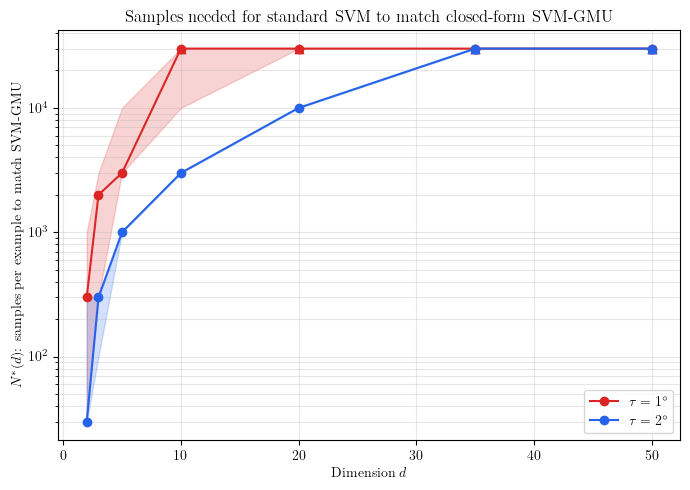

In [5]:
# Full 30-seed sweep (cached). First run is slow; re-runs load the cache.
FORCE_RECOMPUTE = False
seeds = C.make_seeds(C.MASTER_SEED, R_SEEDS_FULL)
res = _load_or_run("full", FORCE_RECOMPUTE, D_VALUES_FULL, N_LADDER_FULL, seeds)

# N*(d): samples-to-match vs dimension (saved as high_dim_nstar.pgf).
fig = make_nstar_figure(res)
fig.savefig(C.GRAPHICS_DIR / "high_dim_nstar.pgf", backend="pgf", bbox_inches="tight")
plt.show()

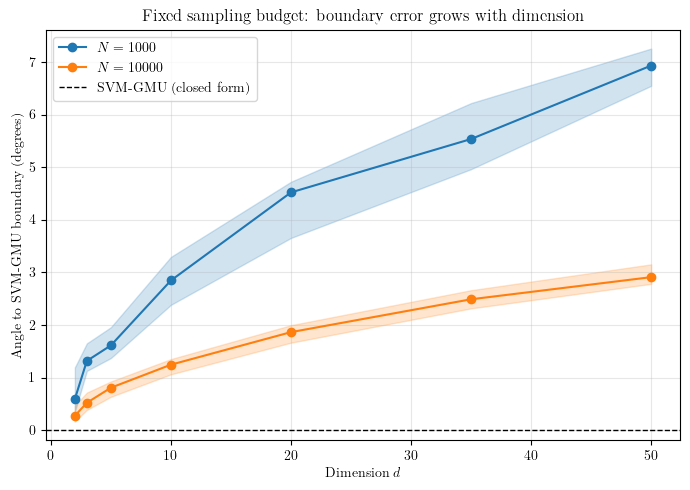

In [6]:
# Fixed-budget angle vs dimension (saved as high_dim_fixed_budget.pgf).
fig = make_fixedbudget_figure(res)
fig.savefig(C.GRAPHICS_DIR / "high_dim_fixed_budget.pgf", backend="pgf", bbox_inches="tight")
plt.show()

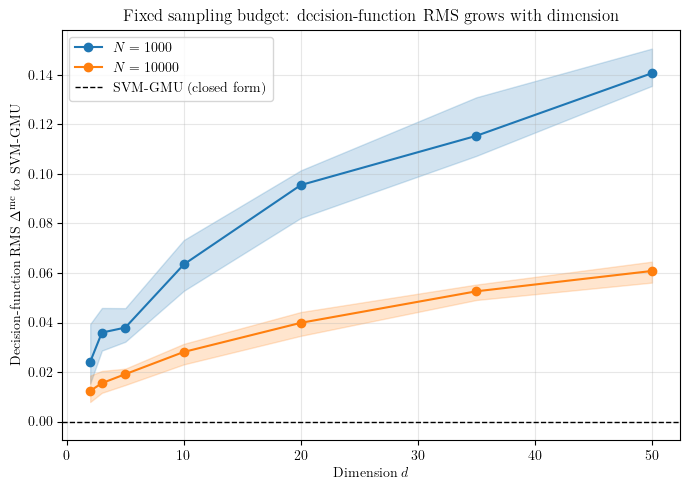

In [7]:
# Fixed-budget decision-function RMS vs dimension (saved as high_dim_rms.pgf).
fig = make_fixedbudget_rms_figure(res)
fig.savefig(C.GRAPHICS_DIR / "high_dim_rms.pgf", backend="pgf", bbox_inches="tight")
plt.show()

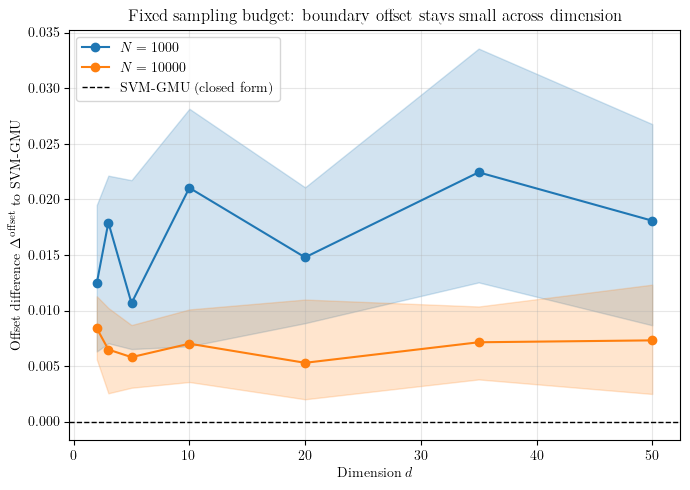

In [8]:
# Fixed-budget offset difference vs dimension (saved as high_dim_offset.pgf).
fig = make_fixedbudget_offset_figure(res)
fig.savefig(C.GRAPHICS_DIR / "high_dim_offset.pgf", backend="pgf", bbox_inches="tight")
plt.show()